In [1]:
import sys
print(sys.executable)

import torch, librosa, sklearn
print("torch", torch.__version__, "| librosa", librosa.__version__, "| sklearn", sklearn.__version__)

c:\Users\Rakshitha\Desktop\mlmini\.venv\Scripts\python.exe
torch 2.14.1+cpu | librosa 1.0.0 | sklearn 1.9.1


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import torch, torch.nn as nn, torch.nn.functional as F
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# where things are
DATA = 'data'          # fma_metadata and fma_small live here
SAVE = 'outputs'       # our results will be saved here
os.makedirs(SAVE, exist_ok=True)

# how we turn sound into a picture (mel-spectrogram)
SR = 22050             # samples per second when loading audio
N_FFT = 2048           # window size for measuring frequencies
HOP = 512              # step between windows: 512/22050 = 23 ms per column
N_MELS = 128           # pitch bands = rows of the picture
FRAMES = 1280          # columns kept per clip, about 29.7 seconds

N_JOBS = 6             # CPU cores used for converting songs (you have 8; leaves 2 free)
device = 'cpu'
torch.manual_seed(42); np.random.seed(42)   # same random choices every run
print('settings ready')

settings ready


In [ ]:
   tracks = pd.read_csv(f'{DATA}/fma_metadata/tracks.csv', index_col=0, header=[0, 1], low_memory=False)
   print('all FMA tracks:', len(tracks))

   small = tracks[tracks[('set', 'subset')] == 'small']  # keep only the 8,000 in fma_small
   df = pd.DataFrame({'genre': small[('track', 'genre_top')]})

   GENRES = sorted(df.genre.unique())
   df['label'] = df.genre.map({g: i for i, g in enumerate(GENRES)})   # genre name -> number 0..7
   df['path'] = [f'{DATA}/fma_small/{t // 1000:03d}/{t:06d}.mp3' for t in df.index] # where each MP3 is


   print('tracks in fma_small:', len(df))
   print(df.genre.value_counts())
   df.head()

all FMA tracks: 106574
tracks in fma_small: 8000
genre
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


,genre,label,path
track_id,,,
2,Hip-Hop,3,data/fma_small/000/000002.mp3
5,Hip-Hop,3,data/fma_small/000/000005.mp3
10,Pop,6,data/fma_small/000/000010.mp3
140,Folk,2,data/fma_small/000/000140.mp3
141,Folk,2,data/fma_small/000/000141.mp3


In [10]:
   df['exists'] = df.path.apply(os.path.exists)
   print('songs in metadata :', len(df))
   print('MP3 files present :', df.exists.sum())
   print('missing files     :', (~df.exists).sum())

songs in metadata : 8000
MP3 files present : 8000
missing files     : 0


missing genres     : 0
duplicate track IDs: 0
missing MP3 files  : 0

songs kept after cleaning: 8000

songs per genre:
genre
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


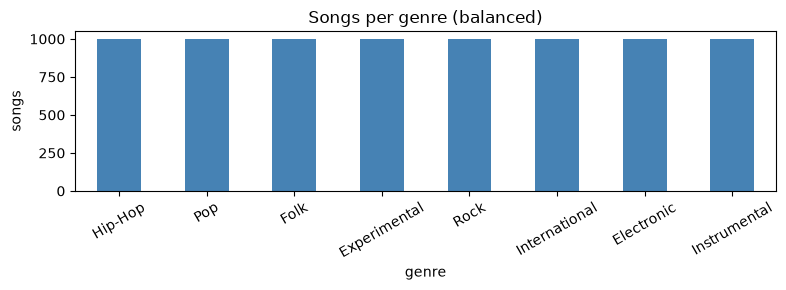

In [11]:
# ---- Data quality checks ----
print('missing genres     :', df.genre.isna().sum())
print('duplicate track IDs:', df.index.duplicated().sum())
print('missing MP3 files  :', (~df.exists).sum())

# remove anything bad (nothing is expected, but this keeps the pipeline safe)
df = df.dropna(subset=['genre'])
df = df[~df.index.duplicated()]
df = df[df.exists]
print('\nsongs kept after cleaning:', len(df))

# class balance
counts = df.genre.value_counts()
print('\nsongs per genre:')
print(counts)
counts.plot.bar(title='Songs per genre (balanced)', figsize=(8, 3), color='steelblue')
plt.ylabel('songs'); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(f'{SAVE}/genre_distribution.png', dpi=150); plt.show()

c:\Users\Rakshitha\Desktop\mlmini\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


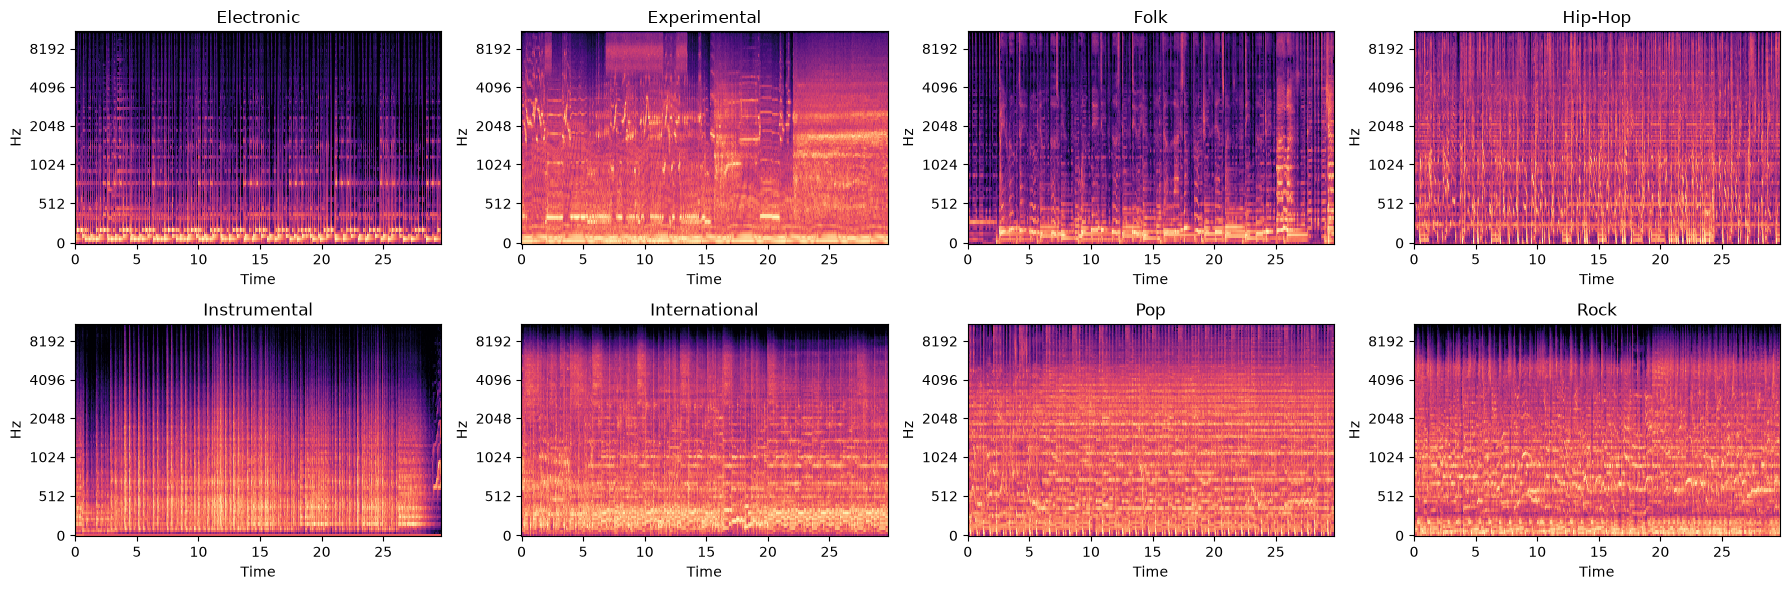

one spectrogram has shape (128, 1280)


In [12]:
def song_to_mel(path, fixed_length=True):
    """MP3 -> log-mel-spectrogram (128 x 1280). Returns None if the file is broken."""
    try:
        y, _ = librosa.load(path, sr=SR, mono=True, duration=30)    # resample to 22,050 Hz, mono
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
                                             hop_length=HOP, n_mels=N_MELS)
        mel = librosa.power_to_db(mel, ref=np.max)                   # loudness -> decibels
    except Exception:
        return None                                                  # corrupt file
    if not fixed_length:
        return mel
    if mel.shape[1] < FRAMES // 2:                                   # under ~15 s of audio: too short
        return None
    if mel.shape[1] < FRAMES:                                        # a bit short: pad with silence
        mel = np.pad(mel, ((0, 0), (0, FRAMES - mel.shape[1])), constant_values=mel.min())
    return mel[:, :FRAMES].astype(np.float16)                        # trim to 1280 columns, save memory

# try it on one example song per genre
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for ax, g in zip(axes.flat, GENRES):
    path = df[df.genre == g].path.iloc[0]
    mel = song_to_mel(path)
    librosa.display.specshow(mel.astype(np.float32), sr=SR, hop_length=HOP,
                             x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(g)
plt.tight_layout(); plt.savefig(f'{SAVE}/example_spectrograms.png', dpi=120); plt.show()
print('one spectrogram has shape', mel.shape)

In [13]:
import time
start = time.time()

# convert every song in parallel on N_JOBS CPU cores
mels = Parallel(n_jobs=N_JOBS, verbose=10)(delayed(song_to_mel)(p) for p in df.path)

ok = np.array([m is not None for m in mels])
print('\nbroken / too-short tracks removed:', df.index[~ok].tolist())

df = df[ok].copy()                                  # keep only good songs
X = np.stack([m for m in mels if m is not None])    # one big array: (songs, 128, 1280)
del mels

np.save(f'{SAVE}/X.npy', X)                         # save, so we never need to redo this
df.to_csv(f'{SAVE}/tracks_used.csv')
print('X shape:', X.shape, f'| took {(time.time() - start) / 60:.1f} min')

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    3.6s
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    3.6s
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed:    4.0s
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed:    4.2s
[Parallel(n_jobs=6)]: Done  29 tasks      | elapsed:    4.3s
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    4.6s
[Parallel(n_jobs=6)]: Done  49 tasks      | elapsed:    4.9s
[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed:    5.2s
[Parallel(n_jobs=6)]: Done  73 tasks      | elapsed:    5.6s
[Parallel(n_jobs=6)]: Done  86 tasks      | elapsed:    6.0s
[Parallel(n_jobs=6)]: Done 101 tasks      | elapsed:    6.4s
[Parallel(n_jobs=6)]: Done 116 tasks      | elapsed:    6.8s
[Parallel(n_jobs=6)]: Done 133 tasks      | elapsed:    7.3s
[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed:    7.8s
[Parallel(n_jobs=6)]: Done 169 tasks      | elapsed:    8.3s
[Parallel(


broken / too-short tracks removed: [98565, 98567, 98569, 99134, 108925, 133297]
X shape: (7994, 128, 1280) | took 4.9 min


In [14]:
y = df.label.values
all_idx = np.arange(len(df))

# 70% train, then split the remaining 30% into 20% validation + 10% test
train_idx, rest = train_test_split(all_idx, train_size=0.70, stratify=y, random_state=42)
val_idx, test_idx = train_test_split(rest, train_size=2/3, stratify=y[rest], random_state=42)
print('train:', len(train_idx), '| validation:', len(val_idx), '| test:', len(test_idx))

# check every genre is represented equally in each part
split_table = pd.DataFrame({
    'train': pd.Series(y[train_idx]).map(dict(enumerate(GENRES))).value_counts(),
    'val':   pd.Series(y[val_idx]).map(dict(enumerate(GENRES))).value_counts(),
    'test':  pd.Series(y[test_idx]).map(dict(enumerate(GENRES))).value_counts()})
print(split_table)

# normalisation statistics: computed from TRAINING songs only (no peeking at test data)
sample = X[np.random.default_rng(0).choice(train_idx, 500, replace=False)].astype(np.float32)
MEAN, STD = float(sample.mean()), float(sample.std())
print(f'\nnormalise with: mean = {MEAN:.1f} dB, std = {STD:.1f} dB')

train: 5595 | validation: 1599 | test: 800
               train  val  test
Electronic       699  200   100
Experimental     699  200   100
Folk             700  200   100
Hip-Hop          698  199   100
Instrumental     700  200   100
International    700  200   100
Pop              700  200   100
Rock             699  200   100

normalise with: mean = -43.9 dB, std = 16.3 dB


In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# 140 summary numbers per song: 20 MFCCs x 7 statistics (mean, std, min, max, ...)
features = pd.read_csv(f'{DATA}/fma_metadata/features.csv', index_col=0, header=[0, 1, 2])
mfcc = features['mfcc'].loc[df.index].values
print('baseline features per song:', mfcc.shape[1])

baselines = {
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'MLP': MLPClassifier(max_iter=500, random_state=0),
    'SVM': SVC(),
}
baseline_acc = {}
for name, model_ in baselines.items():
    pipe = make_pipeline(StandardScaler(), model_)          # scale features, then classify
    pipe.fit(mfcc[train_idx], y[train_idx])                  # learn from TRAIN songs
    baseline_acc[name] = 100 * pipe.score(mfcc[test_idx], y[test_idx])   # score on TEST songs
    print(f'{name:20s} test accuracy: {baseline_acc[name]:.1f}%')

baseline features per song: 140
KNN                  test accuracy: 50.4%
Logistic Regression  test accuracy: 53.5%
MLP                  test accuracy: 49.5%
SVM                  test accuracy: 59.5%


In [16]:
class SongNet(nn.Module):
    def __init__(self, n_genres=8):
        super().__init__()
        def block(c_in, c_out):                      # one CNN block
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, kernel_size=3, padding=1),   # learn short sound patterns
                nn.BatchNorm1d(c_out),                              # keep values stable
                nn.ReLU(),                                          # non-linearity
                nn.MaxPool1d(2),                                    # halve the time length
                nn.Dropout(0.3))                                    # randomly drop 30% (prevents memorising)
        self.cnn = nn.Sequential(block(N_MELS, 256), block(256, 256), block(256, 256))
        self.gru = nn.GRU(256, 128, num_layers=2, batch_first=True, dropout=0.3)   # memory over time
        self.out = nn.Linear(128, n_genres)                                       # 8 genre scores

    def forward(self, x):                   # x: (batch, 128 pitch bands, time)
        h = self.cnn(x)                     # -> (batch, 256 features, time / 8)
        h, _ = self.gru(h.transpose(1, 2))  # -> (batch, time / 8, 128)   reads left to right
        return self.out(h)                  # -> (batch, time / 8, 8)     a prediction at EVERY step

def clip_probs(step_scores):                # average the per-step probabilities -> one answer per clip
    return F.softmax(step_scores, dim=-1).mean(dim=1)

def loss_fn(step_scores, labels):           # how wrong were we?
    probs = clip_probs(step_scores)
    return F.nll_loss(torch.log(probs + 1e-8), labels), probs

model = SongNet(len(GENRES)).to(device)
print(model)
print('trainable parameters:', sum(p.numel() for p in model.parameters()))

SongNet(
  (cnn): Sequential(
    (0): Sequential(
      (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout(p=0.3, inplace=False)
    )
    (2): Sequential(
      (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, di

In [17]:
class MelDataset(torch.utils.data.Dataset):
    def __init__(self, indices, crop=None):
        self.indices, self.crop = indices, crop
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        j = self.indices[i]
        mel = (X[j].astype(np.float32) - MEAN) / STD          # normalise
        if self.crop:                                          # training only: random 15-second piece
            start = np.random.randint(0, FRAMES - self.crop + 1)
            mel = mel[:, start:start + self.crop]
        return torch.from_numpy(mel), int(y[j])

# num_workers=0 is required for notebooks on Windows
train_loader = torch.utils.data.DataLoader(MelDataset(train_idx, crop=640), batch_size=32, shuffle=True, num_workers=0)
val_loader   = torch.utils.data.DataLoader(MelDataset(val_idx),  batch_size=32, num_workers=0)
test_loader  = torch.utils.data.DataLoader(MelDataset(test_idx), batch_size=32, num_workers=0)

torch.set_num_threads(8)        # use all 8 CPU cores for the maths

# quick timing test: one training batch
import time
xb, yb = next(iter(train_loader))
print('one batch:', xb.shape, '(32 songs x 128 pitch bands x 640 time columns)')
t = time.time()
loss, _ = loss_fn(model(xb), yb); loss.backward()
sec = time.time() - t
print(f'one batch takes {sec:.2f} s  ->  one epoch ~ {sec * len(train_loader) / 60:.1f} min')
print('loss before any training:', round(loss.item(), 3), '(random guessing = ln 8 = 2.079)')

one batch: torch.Size([32, 128, 640]) (32 songs x 128 pitch bands x 640 time columns)
one batch takes 1.90 s  ->  one epoch ~ 5.5 min
loss before any training: 2.06 (random guessing = ln 8 = 2.079)


In [18]:
# save everything Colab needs to continue exactly where we are
np.savez(f'{SAVE}/split.npz', train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
         MEAN=MEAN, STD=STD)
df.to_csv(f'{SAVE}/tracks_used.csv')
pd.Series(baseline_acc).to_csv(f'{SAVE}/baseline_results.csv')
print(os.listdir(SAVE))

['baseline_results.csv', 'example_spectrograms.png', 'genre_distribution.png', 'split.npz', 'tracks_used.csv', 'X.npy']


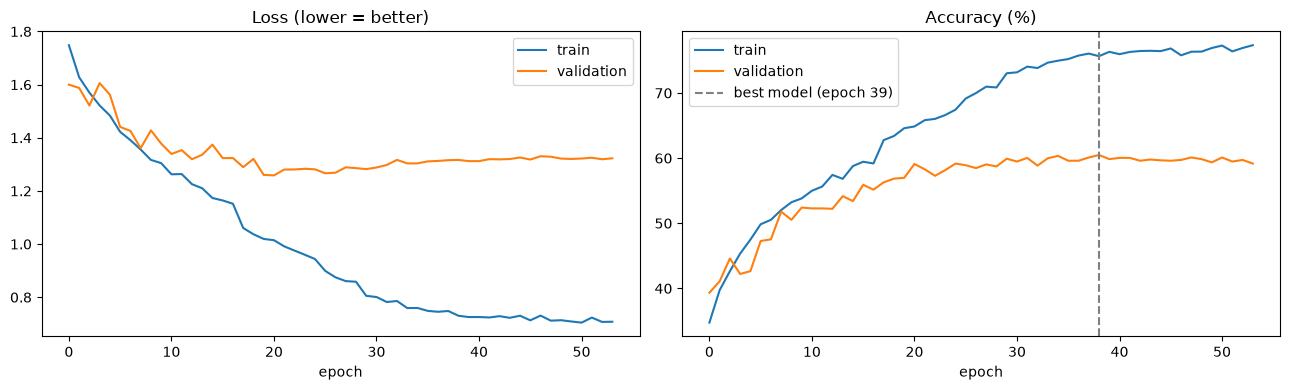

best epoch 39: validation 60.5%, train 75.7%


In [19]:
h = pd.read_csv(f'{SAVE}/history.csv')
best = h.val_acc.idxmax()                        # the epoch whose model we kept

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4))
a.plot(h.train_loss, label='train'); a.plot(h.val_loss, label='validation')
a.set_title('Loss (lower = better)'); a.set_xlabel('epoch'); a.legend()
b.plot(h.train_acc, label='train'); b.plot(h.val_acc, label='validation')
b.axvline(best, color='grey', ls='--', label=f'best model (epoch {best + 1})')
b.set_title('Accuracy (%)'); b.set_xlabel('epoch'); b.legend()
plt.tight_layout(); plt.savefig(f'{SAVE}/training_curves.png', dpi=150); plt.show()
print(f'best epoch {best + 1}: validation {h.val_acc[best]:.1f}%, train {h.train_acc[best]:.1f}%')

In [20]:
# load the best model trained in Colab (map_location='cpu' because your laptop has no GPU)
ckpt = torch.load(f'{SAVE}/songnet.pt', map_location='cpu')
model = SongNet(len(GENRES))
model.load_state_dict(ckpt['model'])
model.eval()                                     # evaluation mode: dropout off

# predict all 800 test songs (never seen during training or model selection)
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds.append(clip_probs(model(xb)).argmax(1).numpy())
preds = np.concatenate(preds)
true = y[test_idx]

test_acc = 100 * (preds == true).mean()
print(f'SongNet TEST accuracy: {test_acc:.1f}%   ({(preds == true).sum()} of {len(true)} songs correct)\n')
print(classification_report(true, preds, target_names=GENRES, digits=3))

SongNet TEST accuracy: 63.0%   (504 of 800 songs correct)

               precision    recall  f1-score   support

   Electronic      0.591     0.650     0.619       100
 Experimental      0.557     0.490     0.521       100
         Folk      0.673     0.700     0.686       100
      Hip-Hop      0.809     0.720     0.762       100
 Instrumental      0.576     0.680     0.624       100
International      0.643     0.740     0.688       100
          Pop      0.500     0.290     0.367       100
         Rock      0.653     0.770     0.706       100

     accuracy                          0.630       800
    macro avg      0.625     0.630     0.622       800
 weighted avg      0.625     0.630     0.622       800



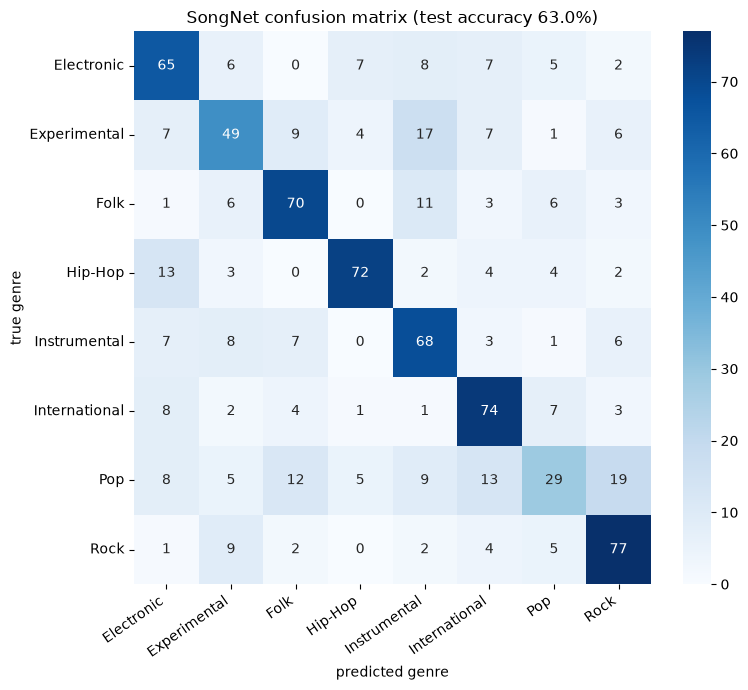

,model,test accuracy (%)
0,Random guess,12.5
1,KNN,50.4
2,Logistic Regression,53.5
3,MLP,49.5
4,SVM,59.5
5,SongNet (ours),63.0
6,Stanford SongNet (paper),65.2


In [21]:
# which genres get confused with which?
cm = confusion_matrix(true, preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel('predicted genre'); plt.ylabel('true genre')
plt.title(f'SongNet confusion matrix (test accuracy {test_acc:.1f}%)')
plt.xticks(rotation=35, ha='right'); plt.tight_layout()
plt.savefig(f'{SAVE}/confusion_matrix.png', dpi=150); plt.show()

# final comparison table
results = pd.DataFrame({
    'model': ['Random guess', *baseline_acc.keys(), 'SongNet (ours)', 'Stanford SongNet (paper)'],
    'test accuracy (%)': [12.5, *baseline_acc.values(), test_acc, 65.2]}).round(1)
results.to_csv(f'{SAVE}/results.csv', index=False)
results

after  3.0 s -> Folk           75.8%
after  5.9 s -> Folk           50.2%
after  8.9 s -> Folk           66.7%
after 11.9 s -> Folk           73.1%
after 14.9 s -> Folk           73.8%
after 17.8 s -> Folk           70.9%
after 20.8 s -> Folk           61.5%
after 23.8 s -> Folk           54.1%
after 26.7 s -> Folk           48.1%
after 29.7 s -> Instrumental   51.5%


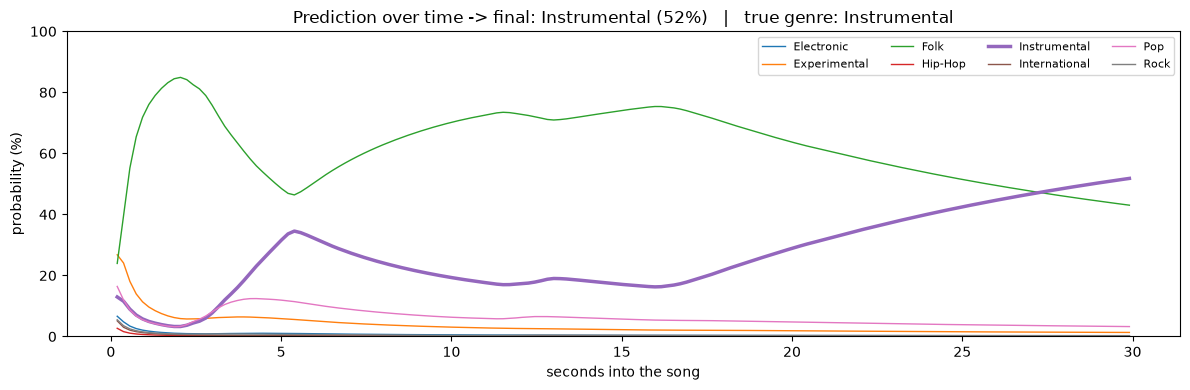

In [22]:
from IPython.display import Audio, display

STEP_SEC = 8 * HOP / SR        # one model step = 8 spectrogram columns = 0.186 s

def live_prediction(path, true_genre=None):
    mel = song_to_mel(path, fixed_length=False)                      # same preprocessing as training
    x = torch.from_numpy((mel - MEAN) / STD).float()[None]           # normalise, add batch dimension
    with torch.no_grad():
        step_probs = F.softmax(model(x), dim=-1)[0].numpy()         # genre probabilities at EVERY step
    running = step_probs.cumsum(0) / np.arange(1, len(step_probs) + 1)[:, None]   # average so far
    seconds = np.arange(1, len(running) + 1) * STEP_SEC

    display(Audio(path))                                             # play button for the song
    # print how the guess changes every ~3 seconds
    for k in range(int(3 / STEP_SEC) - 1, len(running), int(3 / STEP_SEC)):
        g = running[k].argmax()
        print(f'after {seconds[k]:4.1f} s -> {GENRES[g]:<14s} {running[k, g] * 100:4.1f}%')

    plt.figure(figsize=(12, 4))
    for g, name in enumerate(GENRES):
        plt.plot(seconds, running[:, g] * 100, label=name, lw=2.5 if g == running[-1].argmax() else 1)
    final = GENRES[running[-1].argmax()]
    title = f'Prediction over time -> final: {final} ({running[-1].max() * 100:.0f}%)'
    if true_genre:
        title += f'   |   true genre: {true_genre}'
    plt.title(title); plt.xlabel('seconds into the song'); plt.ylabel('probability (%)')
    plt.legend(ncol=4, fontsize=8); plt.ylim(0, 100); plt.tight_layout(); plt.show()

# try it on a song from the TEST set (the model never saw it in training)
k = test_idx[0]
live_prediction(df.path.iloc[k], true_genre=df.genre.iloc[k])

In [23]:
import shutil
DEMO = 'demo_songs'
os.makedirs(DEMO, exist_ok=True)

position = {k: i for i, k in enumerate(test_idx)}       # where each test song is in 'preds'

for g in GENRES:
    for k in test_idx[y[test_idx] == GENRES.index(g)]:
        if preds[position[k]] == y[k]:                  # first correctly predicted test song of this genre
            name = f"{g.replace('-', '')}_{df.index[k]:06d}.mp3"
            shutil.copy(df.path.iloc[k], f'{DEMO}/{name}')
            print('copied', name)
            break
print('\nsongs in', DEMO, ':', sorted(os.listdir(DEMO)))

copied Electronic_052633.mp3
copied Experimental_037041.mp3
copied Folk_110439.mp3
copied HipHop_098577.mp3
copied Instrumental_123487.mp3
copied International_004849.mp3
copied Pop_119187.mp3
copied Rock_037859.mp3

songs in demo_songs : ['Electronic_052633.mp3', 'Experimental_037041.mp3', 'Folk_110439.mp3', 'HipHop_098577.mp3', 'Instrumental_123487.mp3', 'International_004849.mp3', 'Pop_119187.mp3', 'Rock_037859.mp3']


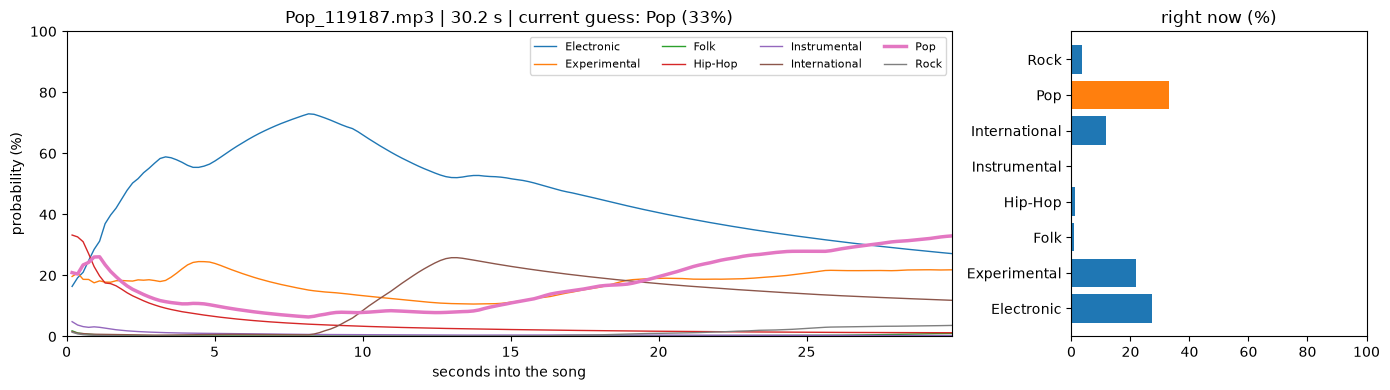

FINAL ANSWER: Pop (33%)


In [28]:
import tkinter as tk
from tkinter import filedialog
from IPython.display import clear_output

DEMO = 'demo_songs'
STEP_SEC = 8 * HOP / SR            # one model step = 0.186 s

def choose_song():
    """opens a normal Windows 'Open file' window, starting in the demo_songs folder"""
    root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
    path = filedialog.askopenfilename(title='Choose a song', initialdir=os.path.abspath(DEMO),
                                      filetypes=[('Audio files', '*.mp3 *.wav *.flac *.ogg *.m4a')])
    root.destroy()
    return path

def real_time_demo(path, seconds=30):
    # 1) same preprocessing as training
    y_, _ = librosa.load(path, sr=SR, mono=True, duration=seconds)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(
        y=y_, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS), ref=np.max)
    x = torch.from_numpy((mel - MEAN) / STD).float()[None]
    # 2) genre probabilities at every 0.19 s step (the model only looks backwards in time)
    model.eval()
    with torch.no_grad():
        step_probs = F.softmax(model(x), dim=-1)[0].numpy()
    running = step_probs.cumsum(0) / np.arange(1, len(step_probs) + 1)[:, None]
    t = np.arange(1, len(running) + 1) * STEP_SEC

    # 3) start playing the song and reveal the predictions in sync with the music
    os.startfile(path)
    start = time.time()
    while True:
        now = time.time() - start
        n = min(len(running), max(1, int(now / STEP_SEC)))
        best = running[n - 1].argmax()
        clear_output(wait=True)
        fig, (a, b) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        for g, name in enumerate(GENRES):
            a.plot(t[:n], running[:n, g] * 100, label=name, lw=2.5 if g == best else 1)
        a.set_xlim(0, t[-1]); a.set_ylim(0, 100); a.legend(ncol=4, fontsize=8)
        a.set_xlabel('seconds into the song'); a.set_ylabel('probability (%)')
        a.set_title(f'{os.path.basename(path)} | {now:4.1f} s | current guess: '
                    f'{GENRES[best]} ({running[n-1, best] * 100:.0f}%)')
        b.barh(GENRES, running[n - 1] * 100,
               color=['tab:orange' if g == best else 'tab:blue' for g in range(len(GENRES))])
        b.set_xlim(0, 100); b.set_title('right now (%)')
        plt.tight_layout(); plt.show()
        if n >= len(running):
            break
        time.sleep(0.5)
    print(f'FINAL ANSWER: {GENRES[running[-1].argmax()]} ({running[-1].max() * 100:.0f}%)')

# ---- run the demo ----
song = choose_song()
print('analysing:', os.path.basename(song))
real_time_demo(song)


========== Hip-Hop song (track 98577) | model was RIGHT ==========


after  3.0 s -> Hip-Hop        93.6%
after  5.9 s -> Hip-Hop        96.8%
after  8.9 s -> Hip-Hop        97.8%
after 11.9 s -> Hip-Hop        98.4%
after 14.9 s -> Hip-Hop        98.7%
after 17.8 s -> Hip-Hop        98.9%
after 20.8 s -> Hip-Hop        99.1%
after 23.8 s -> Hip-Hop        99.2%
after 26.7 s -> Hip-Hop        99.3%
after 29.7 s -> Hip-Hop        99.3%


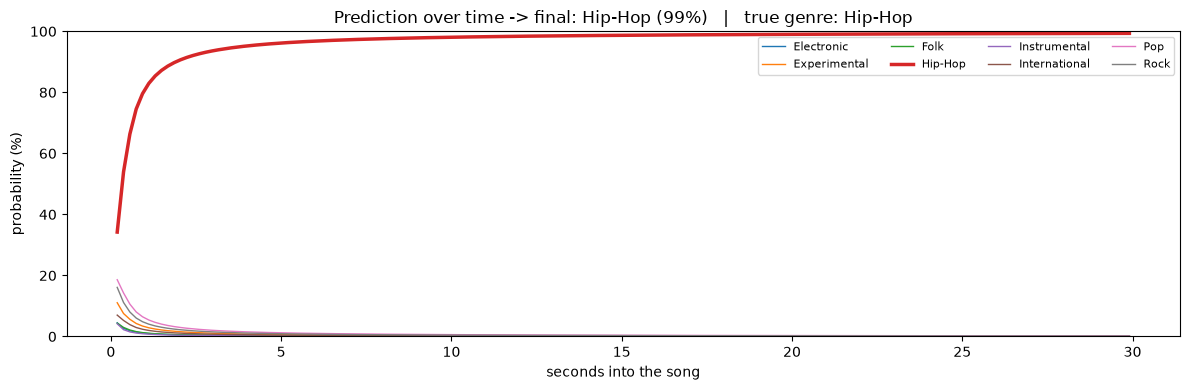


========== Rock song (track 37859) | model was RIGHT ==========


after  3.0 s -> Rock           80.2%
after  5.9 s -> Rock           87.0%
after  8.9 s -> Rock           85.1%
after 11.9 s -> Rock           87.9%
after 14.9 s -> Rock           82.0%
after 17.8 s -> Rock           81.8%
after 20.8 s -> Rock           82.0%
after 23.8 s -> Rock           78.4%
after 26.7 s -> Rock           77.8%
after 29.7 s -> Rock           73.4%


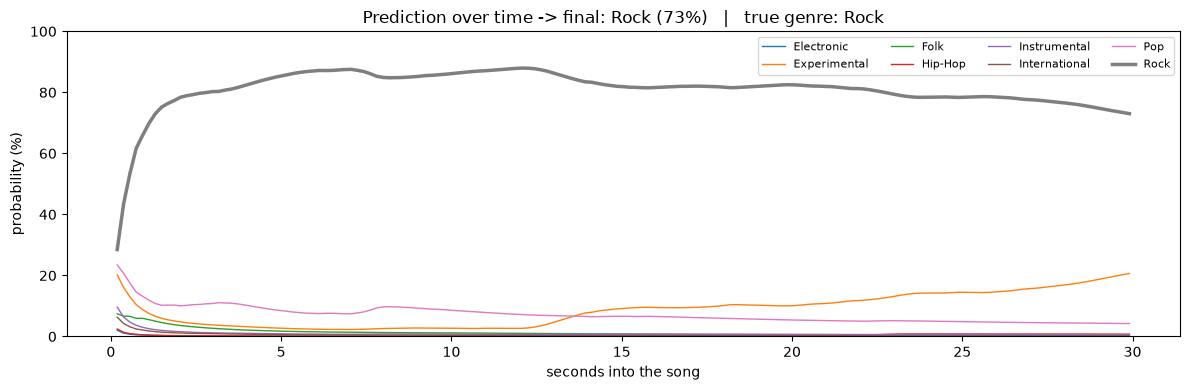


========== International song (track 4849) | model was RIGHT ==========


after  3.0 s -> International  96.5%
after  5.9 s -> International  98.2%
after  8.9 s -> International  98.7%
after 11.9 s -> International  99.0%
after 14.9 s -> International  99.2%
after 17.8 s -> International  99.3%
after 20.8 s -> International  99.4%
after 23.8 s -> International  99.5%
after 26.7 s -> International  99.5%
after 29.7 s -> International  99.6%


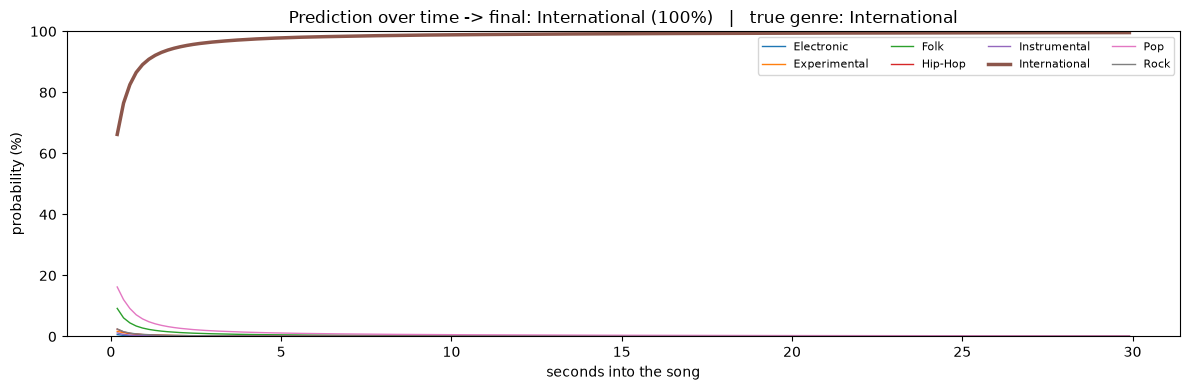


========== Pop song (track 22476) | model was WRONG ==========


after  3.0 s -> Rock           86.3%
after  5.9 s -> Rock           82.0%
after  8.9 s -> Rock           82.1%
after 11.9 s -> Rock           82.1%
after 14.9 s -> Rock           83.7%
after 17.8 s -> Rock           85.9%
after 20.8 s -> Rock           86.8%
after 23.8 s -> Rock           88.1%
after 26.7 s -> Rock           89.2%
after 29.7 s -> Rock           90.0%


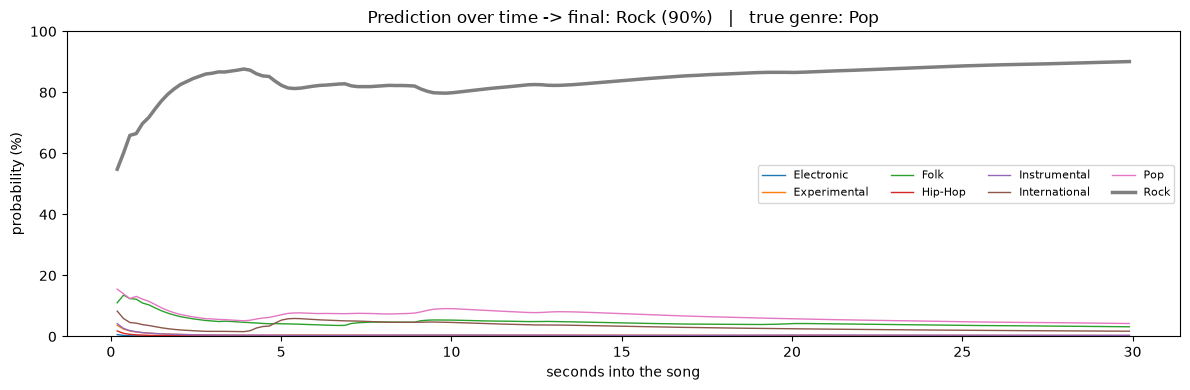

In [29]:
position = {k: i for i, k in enumerate(test_idx)}       # where each test song is in 'preds'

def pick(genre, correct=True):
    """first test song of this genre that the model got right (or wrong)"""
    for k in test_idx[y[test_idx] == GENRES.index(genre)]:
        if (preds[position[k]] == y[k]) == correct:
            return k

for genre, correct in [('Hip-Hop', True), ('Rock', True), ('International', True), ('Pop', False)]:
    k = pick(genre, correct)
    print(f'\n========== {genre} song (track {df.index[k]}) | model was {"RIGHT" if correct else "WRONG"} ==========')
    live_prediction(df.path.iloc[k], true_genre=df.genre.iloc[k])

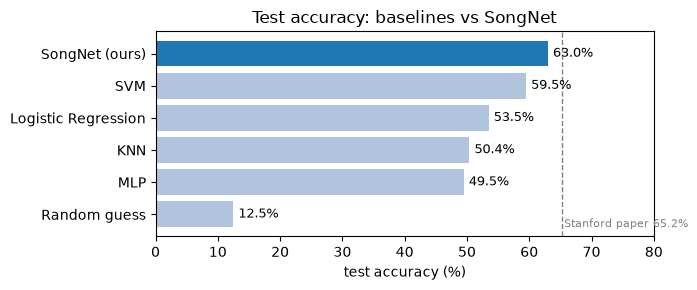

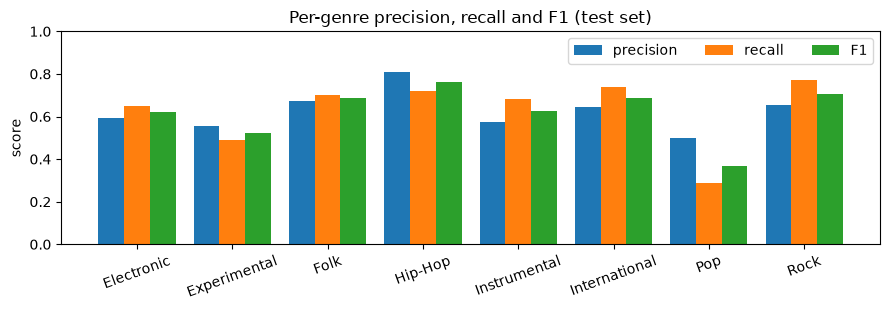

In [30]:
from sklearn.metrics import precision_recall_fscore_support

# Figure: test accuracy of all models
r = results[results.model != 'Stanford SongNet (paper)'].sort_values('test accuracy (%)')
fig, ax = plt.subplots(figsize=(7, 3))
colors = ['tab:blue' if 'ours' in m else 'lightsteelblue' for m in r.model]
ax.barh(r.model, r['test accuracy (%)'], color=colors)
for k, v in enumerate(r['test accuracy (%)']):
    ax.text(v + 0.8, k, f'{v:.1f}%', va='center', fontsize=9)
ax.axvline(65.2, color='grey', ls='--', lw=1); ax.text(65.6, -0.4, 'Stanford paper 65.2%', fontsize=8, color='grey')
ax.set_xlim(0, 80); ax.set_xlabel('test accuracy (%)'); ax.set_title('Test accuracy: baselines vs SongNet')
plt.tight_layout(); plt.savefig(f'{SAVE}/comparison.png', dpi=150); plt.show()

# Figure: precision, recall and F1 per genre
p, r_, f, _ = precision_recall_fscore_support(true, preds)
x = np.arange(len(GENRES)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(x - w, p, w, label='precision'); ax.bar(x, r_, w, label='recall'); ax.bar(x + w, f, w, label='F1')
ax.set_xticks(x); ax.set_xticklabels(GENRES, rotation=20); ax.set_ylim(0, 1); ax.set_ylabel('score')
ax.set_title('Per-genre precision, recall and F1 (test set)'); ax.legend(ncol=3)
plt.tight_layout(); plt.savefig(f'{SAVE}/per_genre_scores.png', dpi=150); plt.show()